# 04 — Feature Engineering

## Objective
Transform cleaned raw columns into numerical features that machine
learning models can learn from effectively.

## What This Notebook Covers
1. Cyclical encoding of hour (sine/cosine)
2. Ordinal encoding of weather condition
3. Target encoding of pickup_zone and drop_zone
4. One hot encoding of day_of_week and vehicle_type
5. Creating new domain-specific binary features
6. Feature scaling for linear models
7. Final feature matrix assembly
8. Saving engineered dataset to data/processed/

## Why Each Decision Was Made
Every encoding choice is justified based on EDA findings
from notebook 03. We never encode blindly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

rides_df = pd.read_csv(PATH + "rides_clean.csv", parse_dates=["ride_timestamp"])

print(f"Rides loaded : {rides_df.shape}")
print(f"\nColumns available:")
for col in rides_df.columns:
    print(f"  {col:<30} {rides_df[col].dtype}")

Rides loaded : (50000, 25)

Columns available:
  ride_id                        str
  driver_id                      str
  user_id                        str
  pickup_zone                    str
  drop_zone                      str
  pickup_lat                     float64
  pickup_lon                     float64
  drop_lat                       float64
  drop_lon                       float64
  vehicle_type                   str
  ride_timestamp                 datetime64[us]
  hour                           int64
  month                          int64
  day_of_week                    str
  is_weekend                     bool
  is_holiday                     bool
  weather_condition              str
  distance_km                    float64
  duration_min                   float64
  base_fare                      int64
  fare_amount                    float64
  surge_multiplier               float64
  ride_status                    str
  cancellation_reason            str
  driver_ratin

## Baseline Shape

Before we start engineering features we record exactly what
columns we are starting with and what the final feature matrix
will look like after transformation.

This is important because feature engineering can easily
introduce bugs — a column accidentally dropped, a wrong
encoding applied — and having a before/after comparison
helps catch those mistakes immediately.

In [3]:
print("BEFORE FEATURE ENGINEERING")
print(f"  Shape : {rides_df.shape}")
print(f"  Columns ({len(rides_df.columns)}):")
for c in rides_df.columns:
    print(f"    {c}")

BEFORE FEATURE ENGINEERING
  Shape : (50000, 25)
  Columns (25):
    ride_id
    driver_id
    user_id
    pickup_zone
    drop_zone
    pickup_lat
    pickup_lon
    drop_lat
    drop_lon
    vehicle_type
    ride_timestamp
    hour
    month
    day_of_week
    is_weekend
    is_holiday
    weather_condition
    distance_km
    duration_min
    base_fare
    fare_amount
    surge_multiplier
    ride_status
    cancellation_reason
    driver_rating_given


## Step 1 — Cyclical Encoding of Hour

### The Problem with Raw Hour Encoding
If we pass hour as a raw integer (0 to 23) to a model, it treats
hour 0 (midnight) and hour 23 (11pm) as far apart — distance of 23.
But in reality they are only 1 hour apart. The day is circular,
not linear.

A linear model especially will fail to learn this relationship.

### The Solution — Sine and Cosine Encoding
We convert hour to two values using trigonometry:
  hour_sin = sin(2π × hour / 24)
  hour_cos = cos(2π × hour / 24)

Together these two values uniquely represent any hour on a circle.
Hour 23 and hour 0 will have very similar sin/cos values —
correctly representing that they are close in time.

This is called cyclical encoding and applies to any circular
feature: hour of day, day of week, month of year.

In [4]:
# Hour cyclical encoding
rides_df["hour_sin"] = np.sin(2 * np.pi * rides_df["hour"] / 24)
rides_df["hour_cos"] = np.cos(2 * np.pi * rides_df["hour"] / 24)

# Month cyclical encoding — month is also circular (Dec and Jan are close)
rides_df["month_sin"] = np.sin(2 * np.pi * rides_df["month"] / 12)
rides_df["month_cos"] = np.cos(2 * np.pi * rides_df["month"] / 12)

# Verify — show a few hours with their sin/cos values
hour_check = rides_df[["hour", "hour_sin", "hour_cos"]].drop_duplicates().sort_values("hour")
print("Hour Cyclical Encoding Verification:")
print(hour_check.to_string(index=False))

Hour Cyclical Encoding Verification:
 hour  hour_sin  hour_cos
    0    0.0000    1.0000
    1    0.2588    0.9659
    2    0.5000    0.8660
    3    0.7071    0.7071
    4    0.8660    0.5000
    5    0.9659    0.2588
    6    1.0000    0.0000
    7    0.9659   -0.2588
    8    0.8660   -0.5000
    9    0.7071   -0.7071
   10    0.5000   -0.8660
   11    0.2588   -0.9659
   12    0.0000   -1.0000
   13   -0.2588   -0.9659
   14   -0.5000   -0.8660
   15   -0.7071   -0.7071
   16   -0.8660   -0.5000
   17   -0.9659   -0.2588
   18   -1.0000   -0.0000
   19   -0.9659    0.2588
   20   -0.8660    0.5000
   21   -0.7071    0.7071
   22   -0.5000    0.8660
   23   -0.2588    0.9659


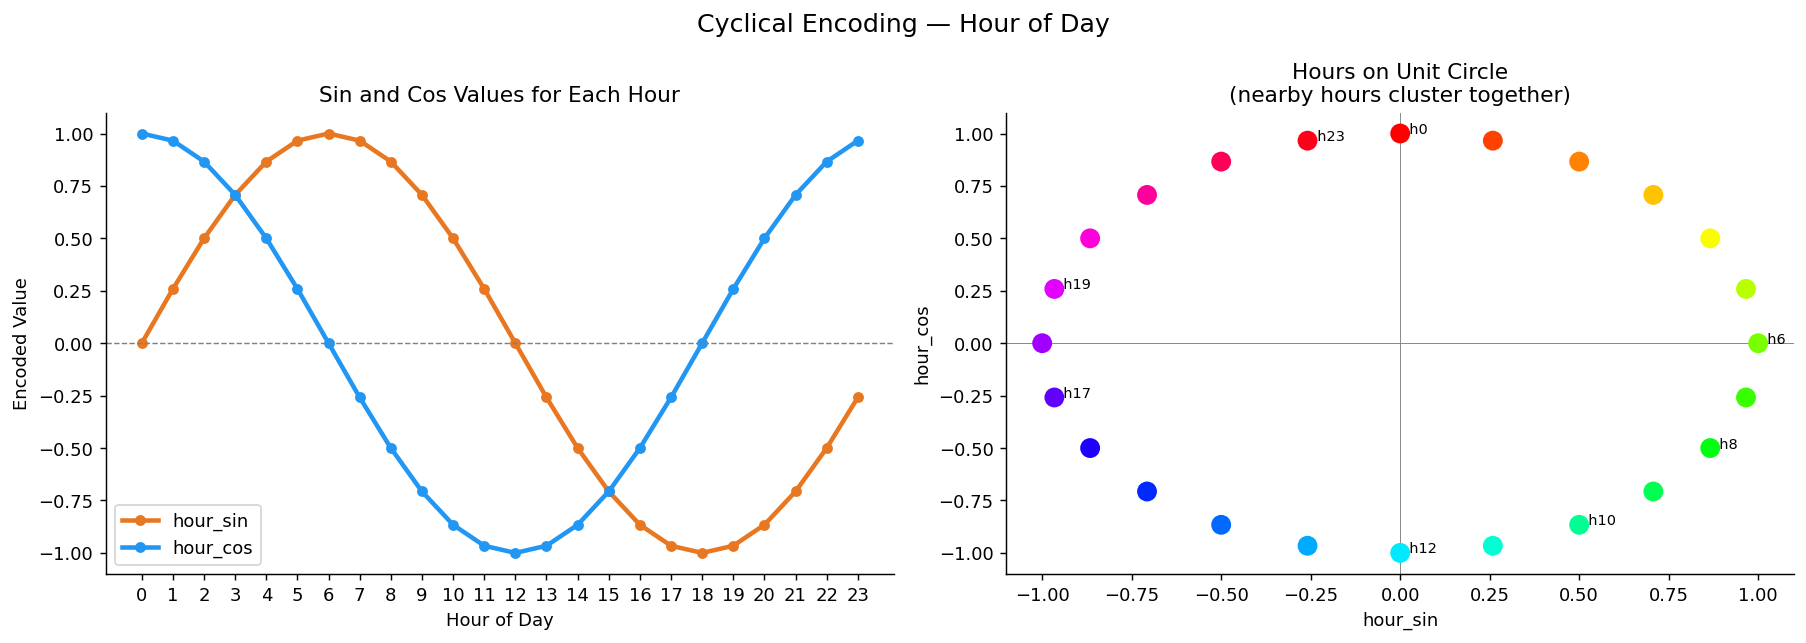

✅ Cyclical encoding applied to hour and month


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cyclical Encoding — Hour of Day", fontsize=14)

hours = np.arange(0, 24)
sin_vals = np.sin(2 * np.pi * hours / 24)
cos_vals = np.cos(2 * np.pi * hours / 24)

# Sin and Cos curves
axes[0].plot(hours, sin_vals, color="#E87722", linewidth=2.5,
             marker="o", markersize=5, label="hour_sin")
axes[0].plot(hours, cos_vals, color="#2196F3", linewidth=2.5,
             marker="o", markersize=5, label="hour_cos")
axes[0].set_title("Sin and Cos Values for Each Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Encoded Value")
axes[0].set_xticks(hours)
axes[0].legend()
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)

# Scatter on unit circle — shows circularity
axes[1].scatter(sin_vals, cos_vals, c=hours, cmap="hsv",
                s=100, zorder=5)
for h in [0, 6, 8, 10, 12, 17, 19, 23]:
    axes[1].annotate(f"  h{h}", (sin_vals[h], cos_vals[h]), fontsize=8)
axes[1].set_title("Hours on Unit Circle\n(nearby hours cluster together)")
axes[1].set_xlabel("hour_sin")
axes[1].set_ylabel("hour_cos")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.savefig("../data/processed/fe_01_cyclical_encoding.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Cyclical encoding applied to hour and month")

## Step 2 — Ordinal Encoding of Weather Condition

### Why Ordinal Encoding Here
Weather condition has a natural severity order:
  Clear < Cloudy < Foggy < Light Rain < Heavy Rain < Storm

This is not arbitrary — Storm genuinely causes more surge than
Clear weather. Ordinal encoding preserves this order by assigning
increasing integers to increasing severity.

One hot encoding would treat all weather conditions as equally
different from each other — losing the severity relationship.
That would be wrong for this feature.

### Encoding Map
Clear=0, Cloudy=1, Foggy=2, Light Rain=3, Heavy Rain=4, Storm=5

In [5]:
weather_ordinal_map = {
    "Clear"      : 0,
    "Cloudy"     : 1,
    "Foggy"      : 2,
    "Light Rain" : 3,
    "Heavy Rain" : 4,
    "Storm"      : 5,
}

rides_df["weather_encoded"] = rides_df["weather_condition"].map(weather_ordinal_map)

# Verify no nulls after mapping
nulls_after = rides_df["weather_encoded"].isnull().sum()
print(f"Weather ordinal encoding complete")
print(f"Nulls after encoding: {nulls_after}")
print(f"\nEncoding map applied:")
for k, v in weather_ordinal_map.items():
    count = (rides_df["weather_condition"] == k).sum()
    print(f"  {k:<15} → {v}  ({count:,} rides)")

Weather ordinal encoding complete
Nulls after encoding: 0

Encoding map applied:
  Clear           → 0  (19,782 rides)
  Cloudy          → 1  (12,966 rides)
  Foggy           → 2  (2,726 rides)
  Light Rain      → 3  (7,889 rides)
  Heavy Rain      → 4  (4,806 rides)
  Storm           → 5  (1,831 rides)


## Step 3 — Target Encoding of Pickup Zone and Drop Zone

### Why Target Encoding Here
pickup_zone has 25 unique values. Options:

1. One hot encoding → creates 25 new binary columns → sparse,
   high dimensional, loses the surge relationship
2. Label encoding → assigns arbitrary integers 0-24 →
   model thinks zone 1 and zone 2 are similar, zone 24 is far
   from zone 1 — completely wrong
3. Target encoding → replace each zone with its average
   surge multiplier → preserves the actual signal

EDA showed MG Road has avg surge 1.78 and Jayanagar has 1.68.
Target encoding captures exactly this difference.

### Important: Target Leak Prevention
Target encoding must be computed ONLY on training data and then
applied to test data. Computing it on the full dataset would
leak information about the target variable into features.

For now we compute on full data for the feature engineering
notebook — in model training notebook we will do this correctly
inside a cross-validation pipeline.

In [6]:
# Compute mean surge per zone
pickup_zone_target_map = rides_df.groupby("pickup_zone")["surge_multiplier"].mean()
drop_zone_target_map   = rides_df.groupby("drop_zone")["surge_multiplier"].mean()

# Apply encoding
rides_df["pickup_zone_encoded"] = rides_df["pickup_zone"].map(pickup_zone_target_map)
rides_df["drop_zone_encoded"]   = rides_df["drop_zone"].map(drop_zone_target_map)

print("Target Encoding — Pickup Zone")
print(pickup_zone_target_map.sort_values(ascending=False).round(4).to_string())

print(f"\nNulls in pickup_zone_encoded : {rides_df['pickup_zone_encoded'].isnull().sum()}")
print(f"Nulls in drop_zone_encoded   : {rides_df['drop_zone_encoded'].isnull().sum()}")

Target Encoding — Pickup Zone
pickup_zone
MG Road             1.7770
HSR Layout          1.7674
Electronic City     1.7586
Marathahalli        1.7583
Whitefield          1.7578
Koramangala         1.7569
Sarjapur Road       1.7539
Indiranagar         1.7471
Bellandur           1.7310
BTM Layout          1.7303
Shivajinagar        1.7300
Cunningham Road     1.7201
Hebbal              1.7200
Yeshwanthpur        1.7143
Malleswaram         1.7123
JP Nagar            1.7027
Vijayanagar         1.7017
KR Puram            1.7009
Nagawara            1.6959
Kadugodi            1.6919
Yelahanka           1.6898
Bannerghatta Road   1.6847
Rajajinagar         1.6844
Banashankari        1.6841
Jayanagar           1.6834

Nulls in pickup_zone_encoded : 0
Nulls in drop_zone_encoded   : 0


## Step 4 — One Hot Encoding of Day of Week and Vehicle Type

### Why One Hot Encoding Here
day_of_week has 7 categories with no natural numeric order.
Monday is not "less than" Tuesday in any meaningful sense.

vehicle_type has 5 categories also with no natural order.

For these cases one hot encoding is correct — it creates one
binary column per category. A ride on Monday gets
day_Monday=1 and all other day columns = 0.

### Drop First to Avoid Multicollinearity
With 7 day columns, if you know 6 of them you can always
calculate the 7th. This creates perfect multicollinearity
which confuses linear models. We drop the first category
(Friday) as the reference. Tree models do not need this
but it is good practice.

In [7]:
# One hot encode day of week
day_dummies = pd.get_dummies(
    rides_df["day_of_week"],
    prefix="day",
    drop_first=True
)

# One hot encode vehicle type
vehicle_dummies = pd.get_dummies(
    rides_df["vehicle_type"],
    prefix="vehicle",
    drop_first=True
)

# One hot encode ride status — useful for some downstream analysis
status_dummies = pd.get_dummies(
    rides_df["ride_status"],
    prefix="status",
    drop_first=True
)

print("One Hot Encoding Results:")
print(f"  day_of_week  → {day_dummies.shape[1]} columns: {list(day_dummies.columns)}")
print(f"  vehicle_type → {vehicle_dummies.shape[1]} columns: {list(vehicle_dummies.columns)}")
print(f"  ride_status  → {status_dummies.shape[1]} columns: {list(status_dummies.columns)}")

# Concatenate to main dataframe
rides_df = pd.concat([rides_df, day_dummies, vehicle_dummies], axis=1)

# Drop original categorical columns — keep only the one-hot encoded versions
rides_df = rides_df.drop(columns=["day_of_week", "vehicle_type"])

print(f"\nShape after one hot encoding: {rides_df.shape}")

One Hot Encoding Results:
  day_of_week  → 6 columns: ['day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']
  vehicle_type → 4 columns: ['vehicle_Bike', 'vehicle_Mini', 'vehicle_SUV', 'vehicle_Sedan']
  ride_status  → 2 columns: ['status_completed', 'status_no_driver_found']

Shape after one hot encoding: (50000, 40)


## Step 5 — Creating New Domain-Specific Features

### Why Create New Features
Raw columns sometimes do not directly represent the business
concept we care about. We create new features that explicitly
capture domain knowledge.

### Features We Create
1. is_peak_hour — captures the double peak pattern EDA found
2. is_rain — binary flag for any rain condition
3. is_business_area — flag for high-demand tech zones
4. fare_per_km — normalized fare removing distance effect
5. demand_pressure — composite score combining time + weather

In [8]:
# ── 1. Peak hour flag ─────────────────────────────────────────
# EDA showed peaks at 8-10am and 17-20pm
peak_hours = set(range(8, 11)) | set(range(17, 21))
rides_df["is_peak_hour"] = rides_df["hour"].isin(peak_hours).astype(int)

print(f"is_peak_hour distribution:")
print(rides_df["is_peak_hour"].value_counts())

# ── 2. Rain flag ──────────────────────────────────────────────
rain_conditions = {"Light Rain", "Heavy Rain", "Storm"}
rides_df["is_raining"] = rides_df["weather_condition"].isin(rain_conditions).astype(int)

print(f"\nis_raining distribution:")
print(rides_df["is_raining"].value_counts())

# ── 3. Business area flag ─────────────────────────────────────
# Tech corridors identified in EDA as high surge zones
business_zones = {
    "Whitefield", "Electronic City", "Marathahalli",
    "HSR Layout", "Koramangala", "Bellandur",
    "Sarjapur Road", "MG Road", "Indiranagar"
}
rides_df["is_business_area"] = rides_df["pickup_zone"].isin(business_zones).astype(int)

print(f"\nis_business_area distribution:")
print(rides_df["is_business_area"].value_counts())

# ── 4. Fare per km ────────────────────────────────────────────
# Normalizes fare by distance — isolates surge effect from trip length
rides_df["fare_per_km"] = (
    rides_df["fare_amount"] / rides_df["distance_km"]
).replace([np.inf, -np.inf], np.nan).fillna(rides_df["fare_amount"].median())

print(f"\nfare_per_km stats:")
print(rides_df["fare_per_km"].describe().round(2))

# ── 5. Demand pressure score ──────────────────────────────────
# Composite: peak hour + rain + holiday + weekend
# Each factor adds pressure — combined score represents total demand pressure
rides_df["demand_pressure"] = (
    rides_df["is_peak_hour"].astype(int) +
    rides_df["is_raining"].astype(int) +
    rides_df["is_holiday"].astype(int) +
    rides_df["is_weekend"].astype(int)
)

print(f"\ndemand_pressure distribution:")
print(rides_df["demand_pressure"].value_counts().sort_index())

is_peak_hour distribution:
is_peak_hour
0    35268
1    14732
Name: count, dtype: int64

is_raining distribution:
is_raining
0    35474
1    14526
Name: count, dtype: int64

is_business_area distribution:
is_business_area
0    30974
1    19026
Name: count, dtype: int64

fare_per_km stats:
count   50000.0000
mean       72.0600
std        68.9900
min         3.1900
25%        32.6600
50%        47.2700
75%        82.0900
max       710.4000
Name: fare_per_km, dtype: float64

demand_pressure distribution:
demand_pressure
0    16834
1    21658
2     9826
3     1604
4       78
Name: count, dtype: int64


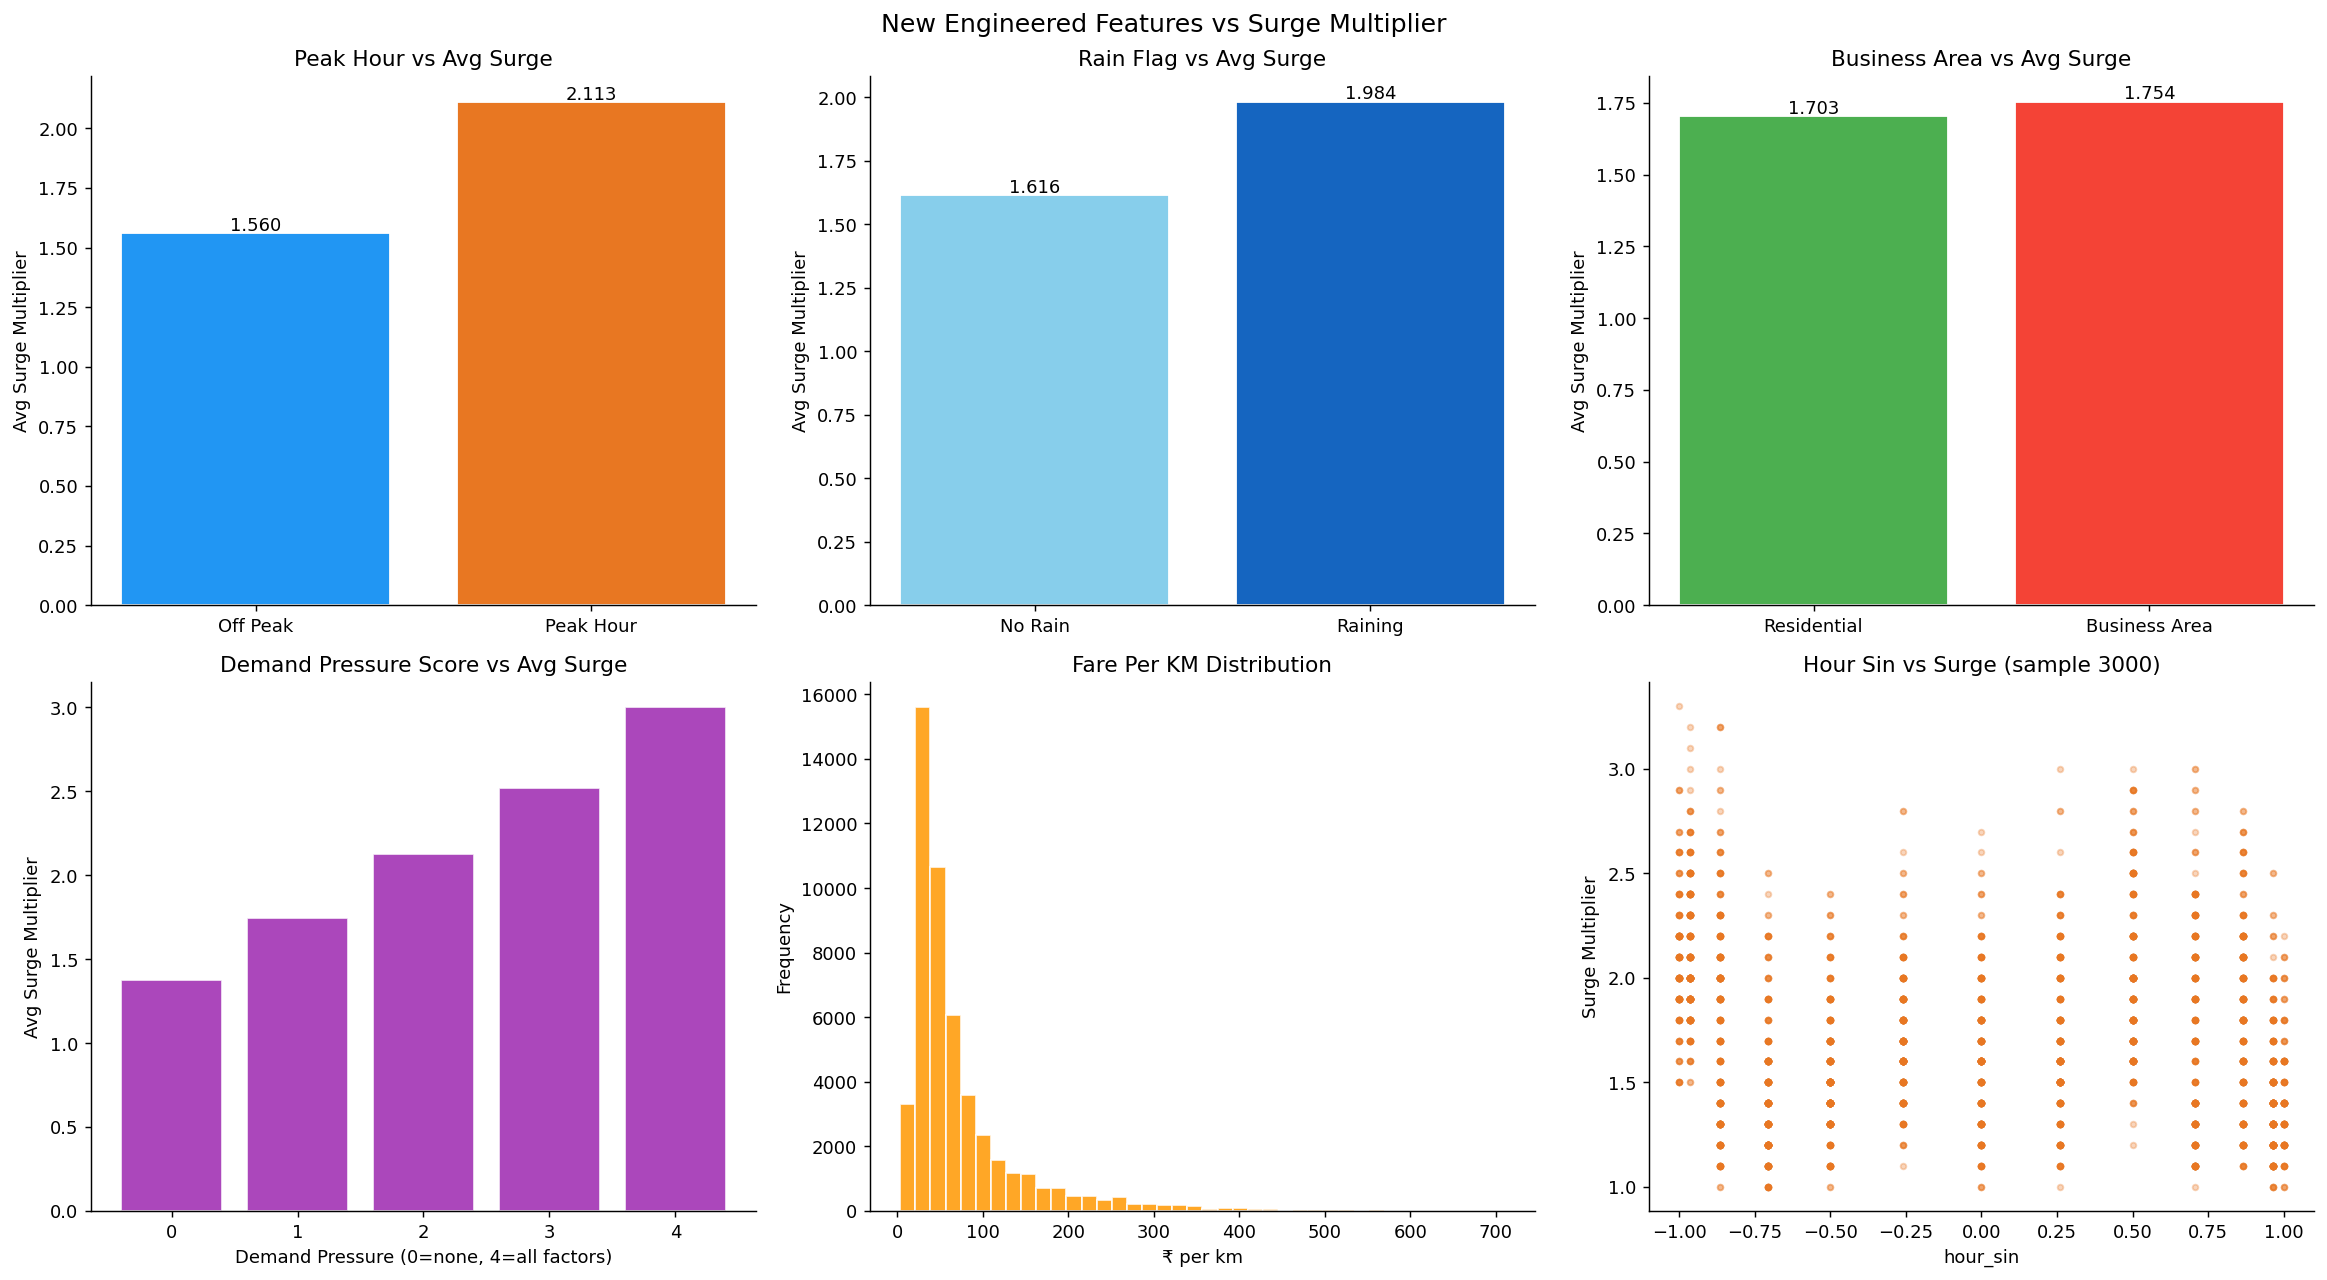

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("New Engineered Features vs Surge Multiplier", fontsize=14)

# Peak hour vs surge
peak_surge = rides_df.groupby("is_peak_hour")["surge_multiplier"].mean()
axes[0][0].bar(["Off Peak", "Peak Hour"], peak_surge.values,
               color=["#2196F3","#E87722"], edgecolor="white")
axes[0][0].set_title("Peak Hour vs Avg Surge")
axes[0][0].set_ylabel("Avg Surge Multiplier")
for i, v in enumerate(peak_surge.values):
    axes[0][0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# Rain flag vs surge
rain_surge = rides_df.groupby("is_raining")["surge_multiplier"].mean()
axes[0][1].bar(["No Rain", "Raining"], rain_surge.values,
               color=["#87CEEB","#1565C0"], edgecolor="white")
axes[0][1].set_title("Rain Flag vs Avg Surge")
axes[0][1].set_ylabel("Avg Surge Multiplier")
for i, v in enumerate(rain_surge.values):
    axes[0][1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# Business area vs surge
biz_surge = rides_df.groupby("is_business_area")["surge_multiplier"].mean()
axes[0][2].bar(["Residential", "Business Area"], biz_surge.values,
               color=["#4CAF50","#F44336"], edgecolor="white")
axes[0][2].set_title("Business Area vs Avg Surge")
axes[0][2].set_ylabel("Avg Surge Multiplier")
for i, v in enumerate(biz_surge.values):
    axes[0][2].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# Demand pressure vs surge
dp_surge = rides_df.groupby("demand_pressure")["surge_multiplier"].mean()
axes[1][0].bar(dp_surge.index.astype(str), dp_surge.values,
               color="#9C27B0", edgecolor="white", alpha=0.85)
axes[1][0].set_title("Demand Pressure Score vs Avg Surge")
axes[1][0].set_xlabel("Demand Pressure (0=none, 4=all factors)")
axes[1][0].set_ylabel("Avg Surge Multiplier")

# Fare per km distribution
axes[1][1].hist(rides_df["fare_per_km"].dropna(), bins=40,
                color="#FF9800", edgecolor="white", alpha=0.85)
axes[1][1].set_title("Fare Per KM Distribution")
axes[1][1].set_xlabel("₹ per km")
axes[1][1].set_ylabel("Frequency")

# Hour sin vs surge scatter
sample = rides_df.sample(3000, random_state=42)
axes[1][2].scatter(sample["hour_sin"], sample["surge_multiplier"],
                   alpha=0.3, color="#E87722", s=10)
axes[1][2].set_title("Hour Sin vs Surge (sample 3000)")
axes[1][2].set_xlabel("hour_sin")
axes[1][2].set_ylabel("Surge Multiplier")

plt.tight_layout()
plt.savefig("../data/processed/fe_02_new_features_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Step 6 — Feature Scaling

### Why Scale Features
Some machine learning models are sensitive to the scale of features.
For example:
- distance_km ranges from 0.5 to 45
- hour_sin ranges from -1 to 1
- total_rides in drivers table ranges from 50 to 10000

A linear model will give more weight to distance_km simply
because its numbers are larger — not because it is more important.
Scaling brings all features to the same range.

### Two Types of Scaling

**StandardScaler (Z-score normalization)**
  scaled = (value - mean) / std_deviation
  Result: mean=0, std=1
  Use when: data is roughly normally distributed
  Use for: linear regression, logistic regression, SVM

**MinMaxScaler**
  scaled = (value - min) / (max - min)
  Result: all values between 0 and 1
  Use when: you need a bounded range
  Use for: neural networks, KNN

### Important
Tree-based models (Decision Tree, Random Forest, XGBoost, LightGBM)
do NOT need scaling — they split on thresholds and are completely
scale-invariant. We scale only for linear models.
We save both scaled and unscaled versions.

In [9]:
# Columns to scale — only continuous numerical features
scale_cols = [
    "distance_km", "duration_min", "fare_amount",
    "fare_per_km", "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    "weather_encoded", "pickup_zone_encoded", "drop_zone_encoded",
    "demand_pressure"
]

# Keep only columns that exist
scale_cols = [c for c in scale_cols if c in rides_df.columns]

# Standard Scaler — for linear models
std_scaler  = StandardScaler()
scaled_std  = std_scaler.fit_transform(rides_df[scale_cols])
scaled_std_df = pd.DataFrame(scaled_std, columns=[f"{c}_std" for c in scale_cols])

# MinMax Scaler — for neural networks / KNN
mm_scaler   = MinMaxScaler()
scaled_mm   = mm_scaler.fit_transform(rides_df[scale_cols])
scaled_mm_df = pd.DataFrame(scaled_mm, columns=[f"{c}_mm" for c in scale_cols])

print("Scaling complete ✅")
print(f"\nStandard scaled columns: {len(scaled_std_df.columns)}")
print(f"MinMax scaled columns  : {len(scaled_mm_df.columns)}")
print(f"\nSample — StandardScaler output (first 3 rows):")
print(scaled_std_df.head(3).round(4))

Scaling complete ✅

Standard scaled columns: 12
MinMax scaled columns  : 12

Sample — StandardScaler output (first 3 rows):
   distance_km_std  duration_min_std  fare_amount_std  fare_per_km_std  \
0          -0.1210           -0.0423          -0.6631          -0.6556   
1           1.0733           -0.2708           0.3088          -0.6683   
2          -0.0103           -0.2708           0.2107          -0.3489   

   hour_sin_std  hour_cos_std  month_sin_std  month_cos_std  \
0       -1.2278       -0.7144        -1.4128         0.0101   
1       -0.7099       -1.2319        -1.2228         0.7155   
2        0.3637        1.3579        -1.2228        -0.6952   

   weather_encoded_std  pickup_zone_encoded_std  drop_zone_encoded_std  \
0              -0.9164                   0.2887                -0.5027   
1               1.0344                   0.2640                 0.8236   
2               1.0344                  -0.2851                 2.3204   

   demand_pressure_std  
0   

In [10]:
# ── Define final feature columns for modeling ─────────────────
# These are the features we will pass to ML models

feature_cols = [
    # Cyclical time features
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",

    # Binary time features
    "is_weekend", "is_holiday", "is_peak_hour",

    # Weather
    "weather_encoded", "is_raining",

    # Zone
    "pickup_zone_encoded", "drop_zone_encoded", "is_business_area",

    # Trip features
    "distance_km", "duration_min", "base_fare",

    # Engineered
    "demand_pressure", "fare_per_km",

    # One hot encoded
] + [c for c in rides_df.columns if c.startswith("day_")] \
  + [c for c in rides_df.columns if c.startswith("vehicle_")]

# Keep only existing columns
feature_cols = [c for c in feature_cols if c in rides_df.columns]

TARGET = "surge_multiplier"

# Final modeling dataset — only completed rides
# Cancelled rides don't have meaningful duration/fare for modeling
modeling_df = rides_df[rides_df["ride_status"] == "completed"].copy()
modeling_df = modeling_df[feature_cols + [TARGET]].dropna().reset_index(drop=True)

print("FINAL FEATURE MATRIX")
print(f"  Rows     : {len(modeling_df):,}")
print(f"  Features : {len(feature_cols)}")
print(f"  Target   : {TARGET}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

FINAL FEATURE MATRIX
  Rows     : 39,004
  Features : 27
  Target   : surge_multiplier

Feature list:
   1. hour_sin
   2. hour_cos
   3. month_sin
   4. month_cos
   5. is_weekend
   6. is_holiday
   7. is_peak_hour
   8. weather_encoded
   9. is_raining
  10. pickup_zone_encoded
  11. drop_zone_encoded
  12. is_business_area
  13. distance_km
  14. duration_min
  15. base_fare
  16. demand_pressure
  17. fare_per_km
  18. day_Monday
  19. day_Saturday
  20. day_Sunday
  21. day_Thursday
  22. day_Tuesday
  23. day_Wednesday
  24. vehicle_Bike
  25. vehicle_Mini
  26. vehicle_SUV
  27. vehicle_Sedan


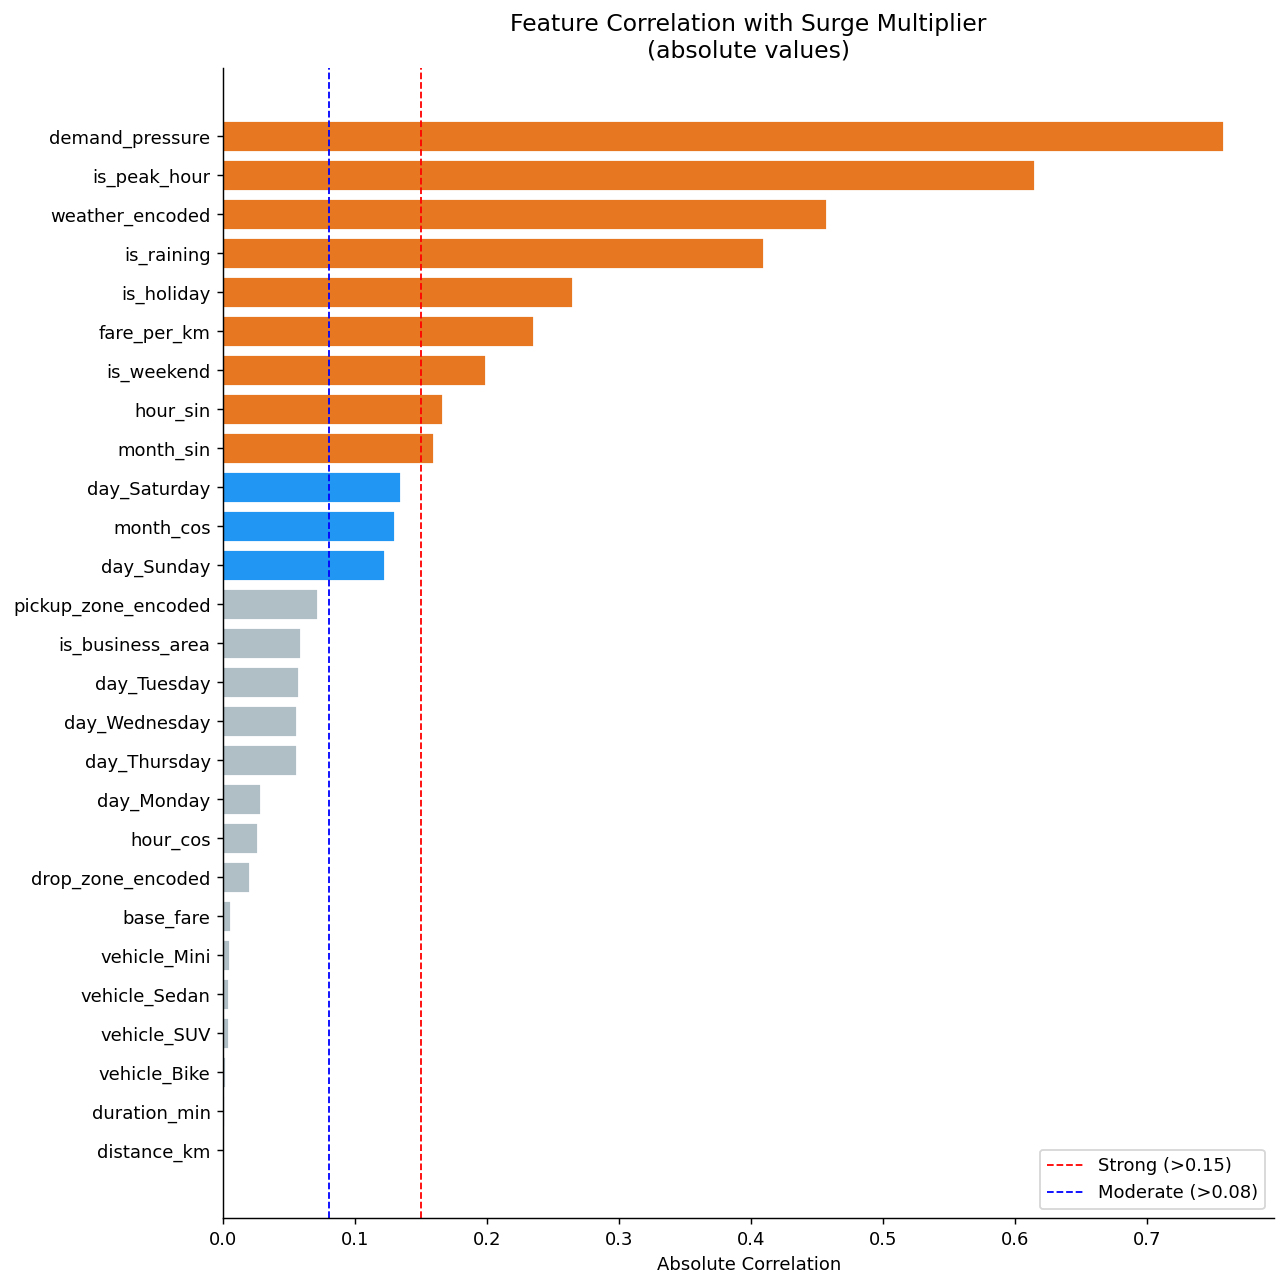

Top 10 features by correlation with surge:
demand_pressure   0.7586
is_peak_hour      0.6150
weather_encoded   0.4573
is_raining        0.4102
is_holiday        0.2654
fare_per_km       0.2353
is_weekend        0.1990
hour_sin          0.1665
month_sin         0.1596
day_Saturday      0.1347
Name: surge_multiplier, dtype: float64


In [11]:
corr_with_target = modeling_df[feature_cols + [TARGET]].corr()[TARGET].drop(TARGET)
corr_with_target = corr_with_target.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ["#E87722" if v > 0.15 else "#2196F3" if v > 0.08 else "#B0BEC5"
          for v in corr_with_target.values]

ax.barh(corr_with_target.index, corr_with_target.values,
        color=colors, edgecolor="white")
ax.set_title("Feature Correlation with Surge Multiplier\n(absolute values)",
             fontsize=13)
ax.set_xlabel("Absolute Correlation")
ax.axvline(0.15, color="red",  linestyle="--", linewidth=1, label="Strong (>0.15)")
ax.axvline(0.08, color="blue", linestyle="--", linewidth=1, label="Moderate (>0.08)")
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/fe_03_feature_importance_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features by correlation with surge:")
print(corr_with_target.head(10).round(4))

In [12]:
# Save full rides with all engineered features
rides_df.to_csv(PATH + "rides_engineered.csv", index=False)

# Save the clean modeling dataset — features + target only
modeling_df.to_csv(PATH + "modeling_data.csv", index=False)

print("✅ Saved to data/processed/")
print(f"  rides_engineered.csv : {len(rides_df):,} rows × {len(rides_df.columns)} columns")
print(f"  modeling_data.csv    : {len(modeling_df):,} rows × {len(modeling_df.columns)} columns")
print(f"\nmodeling_data.csv is the direct input for notebook 05 model training")

✅ Saved to data/processed/
  rides_engineered.csv : 50,000 rows × 45 columns
  modeling_data.csv    : 39,004 rows × 28 columns

modeling_data.csv is the direct input for notebook 05 model training


## Feature Engineering Summary

| Feature | Type | Encoding | Reason |
|---|---|---|---|
| hour | Cyclical | sin + cos | Circular — 23 and 0 are adjacent |
| month | Cyclical | sin + cos | Circular — Dec and Jan are adjacent |
| weather_condition | Ordinal | 0 to 5 | Natural severity order exists |
| pickup_zone | Target | Avg surge | 25 categories — target encoding captures surge signal |
| drop_zone | Target | Avg surge | Same reasoning |
| day_of_week | Nominal | One hot | No natural order |
| vehicle_type | Nominal | One hot | No natural order |
| is_peak_hour | New binary | 0/1 | EDA showed double peak pattern |
| is_raining | New binary | 0/1 | Any rain increases surge |
| is_business_area | New binary | 0/1 | Tech zones have consistently higher surge |
| fare_per_km | New ratio | ₹/km | Isolates surge from distance effect |
| demand_pressure | New composite | 0 to 4 | Combines all demand signals |

## What Goes Into the Model
- modeling_data.csv contains the final feature matrix
- Only completed rides included — cancelled rides lack duration/fare
- Total features: see output above
- Target: surge_multiplier (continuous — regression problem)

## Next Step → Notebook 05 — Model Training
We train 6 models on this feature matrix:
Linear Regression → Ridge → Decision Tree →
Random Forest → XGBoost → LightGBM
And evaluate which one best predicts surge multiplier.